In [3]:
import cudf
import cupy
import matplotlib.pyplot as plt
from cuml.cluster import KMeans
from cuml.metrics.cluster import silhouette_score
from sklearn.neighbors import NearestNeighbors
import joblib
import time

try:
    df = cudf.read_parquet("data_for_clustering.parquet")
    print("File 'data_for_clustering.parquet' loaded successfully !")
except FileNotFoundError:
    print("ERROR: File 'data_for_clustering.parquet' not found.")

if 'df' in locals():
    X = cupy.array(df['pca_features'].to_pandas().tolist())
    print(f"Feature matrix created on GPU with shape: {X.shape}\n")

File 'data_for_clustering.parquet' loaded successfully !
Feature matrix created on GPU with shape: (170653, 8)



## K-Means Clustering

Searching for the optimal k...
For k=2, Silhouette Score = 0.9898, Inertia = 1414359.83
For k=3, Silhouette Score = 0.9637, Inertia = 1267749.55
For k=4, Silhouette Score = 0.8739, Inertia = 1127705.36
For k=5, Silhouette Score = 0.8616, Inertia = 1102138.54
For k=6, Silhouette Score = 0.8559, Inertia = 957733.92
For k=7, Silhouette Score = 0.8579, Inertia = 825087.25
For k=8, Silhouette Score = 0.8580, Inertia = 808831.76
For k=9, Silhouette Score = 0.8514, Inertia = 791869.36
For k=10, Silhouette Score = 0.3440, Inertia = 509785.36
For k=11, Silhouette Score = 0.3443, Inertia = 493157.79
For k=12, Silhouette Score = 0.3444, Inertia = 488183.07
For k=13, Silhouette Score = 0.3444, Inertia = 482226.77
For k=14, Silhouette Score = 0.3444, Inertia = 481020.41
For k=15, Silhouette Score = 0.3150, Inertia = 374885.35
For k=16, Silhouette Score = 0.3152, Inertia = 368200.38
For k=17, Silhouette Score = 0.3150, Inertia = 366712.18
For k=18, Silhouette Score = 0.2938, Inertia = 296022.89
For 

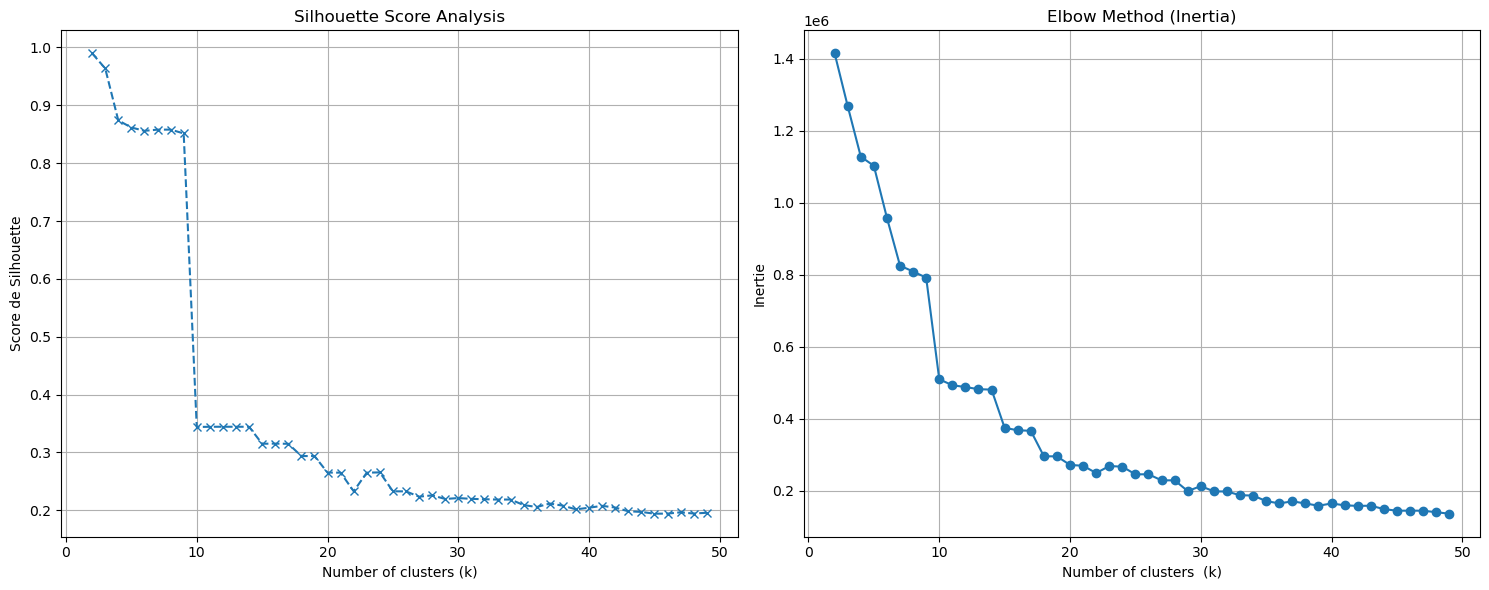

In [4]:
ks = range(2, 50)
sil_scores = []
inertias = []

print("Searching for the optimal k...")
start_time = time.time()

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)

    score = silhouette_score(X, kmeans.labels_)
    sil_scores.append(float(score))

    inertias.append(float(kmeans.inertia_))

    print(f"For k={k}, Silhouette Score = {score:.4f}, Inertia = {kmeans.inertia_:.2f}")

end_time = time.time()
print(f"\nSearch complete in {end_time - start_time:.2f} seconds.")

plt.figure(figsize=(15, 6))

# Silhouette Score Plot
plt.subplot(1, 2, 1)
plt.plot(ks, sil_scores, marker='x', linestyle='--')
plt.title('Silhouette Score Analysis')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score de Silhouette')
plt.grid(True)

# Elbow Method Plot
plt.subplot(1, 2, 2)
plt.plot(ks, inertias, marker='o', linestyle='-')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters  (k)')
plt.ylabel('Inertie')
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
K_OPTIMAL = 9

print(f"\nTraining final model with k={K_OPTIMAL}...")

final_kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42)
final_kmeans.fit(X)

df['cluster'] = final_kmeans.labels_

print(f"Final clustering with k={K_OPTIMAL} is complete!")

final_df_pandas = df.to_pandas()

final_df_pandas.to_csv("spotify_clustered.csv", index=False)

print("\nFinal results saved to 'spotify_clustered_final.csv'")


Training final model with k=9...
Final clustering with k=9 is complete!

Final results saved to 'spotify_clustered_final.csv'


## Nearest Neighbors

In [6]:
nn_model = NearestNeighbors(n_neighbors=30, algorithm='ball_tree')
nn_model.fit(X.get())

model_filename = "nn_model.joblib"
joblib.dump(nn_model, model_filename)

print(f"\nNN model trained and saved successfully as '{model_filename}'!")



NN model trained and saved successfully as 'nn_model.joblib'!
